In [9]:
import pandas as pd
from sklearn.decomposition import PCA
import shap

df = pd.read_csv("../data/palmerpenguins_extended.csv")

y = df["species"]
X = df.drop(columns=["species", "year"])


Pocetna faza ucitavanja podataka. Za ciljnu varijablu (y) odabrana je kolona species, dok su za prediktore (X) zadržani svi relevantni biološki atributi. U skladu sa ranijim statističkim nalazima (u fajlu exploration), kolona year je trajno uklonjena iz skupa podataka jer nije pokazala značajnost za svrstavanje pingvina.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

numerical_features = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]

categorical_features = [
    "island",
    "sex",
    "diet",
    "life_stage",
    "health_metrics"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)


print("--- Analiza Redukcije Dimenzionalnosti ---")
X_train_temp = preprocessor.fit_transform(X_train)
pca_test = PCA(n_components=0.95)
X_pca = pca_test.fit_transform(X_train_temp)

print(f"Broj komponenti pre PCA: {X_train_temp.shape[1]}")
print(f"Broj komponenti nakon PCA: {pca_test.n_components_}")

--- Analiza Redukcije Dimenzionalnosti ---
Broj komponenti pre PCA: 19
Broj komponenti nakon PCA: 9


U okviru pripreme podataka formiran je pipeline koji koristi ColumnTransformer za paralelnu obradu različitih tipova informacija. Numerički atributi su standardizovani pomoću StandardScaler-a, što je proces koji transformiše podatke tako da im srednja vrednost bude 0, a standardna devijacija 1. Ovo sprečava da varijable sa velikim rasponima, poput telesne mase u gramima, dominiraju nad manjim merama poput dubine kljuna. Istovremeno, kategorički podaci su transformisani putem OneHotEncoder-a, koji svaku tekstualnu kategoriju pretvara u zasebnu binarnu kolonu (0 ili 1). Ovim postupkom se izbegava uvođenje lažnog matematičkog poretka među kategorijama (npr. da model ne pomisli da je jedno ostrvo "veće" od drugog).

Drugi deo procesa fokusiran je na redukciju dimenzionalnosti pomoću PCA (Analize glavnih komponenti), sa ciljem da se zadrži 95% varijanse (informacija) originalnog skupa. PCA funkcioniše tako što pronalazi nove, nekorelisane ose (komponente) koje najbolje opisuju širenje podataka, omogućavajući nam da smanjimo broj ulaznih faktora bez značajnog gubitka kvaliteta modela. Rezultat je pokazao da se broj kolona može značajno redukovati, što potvrđuje da su mnoge biološke mere pingvina međusobno povezane i nose slične informacije.

Pre samog treniranja algoritama, izvršena je podela skupa podataka na trening (80%) i test set (20%) korišćenjem funkcije train_test_split. Ovaj postupak je neophodan kako bi se evaluacija modela izvršila na podacima koje algoritam nije video tokom faze učenja, čime se simulira realna primena i proverava sposobnost generalizacije. Ovakva podela sprečava pojavu overfitting.

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ]
)


Prvi algoritam klasifikacije koji se testira je Random Forest.

In [12]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist_rf = {
    "classifier__n_estimators": randint(200, 800),
    "classifier__max_depth": randint(10, 50),
    "classifier__min_samples_split": randint(2, 20),
    "classifier__min_samples_leaf": randint(1, 10),
    "classifier__max_features": ["sqrt", "log2"]
}

random_rf = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_dist_rf,
    n_iter=30,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1,
    random_state=42
)

random_rf.fit(X_train, y_train)


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__max_depth': <scipy.stats....001D36AF32450>, 'classifier__max_features': ['sqrt', 'log2'], 'classifier__min_samples_leaf': <scipy.stats....001D3656C5B50>, 'classifier__min_samples_split': <scipy.stats....001D36F22D5D0>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be th

Nakon definisanja osnovne strukture modela, izvršena je optimizacija pomoću RandomizedSearchCV algoritma, primenjenog nad prethodno kreiranim Pipeline-om. Na ovaj način je omogućeno da se Random Forest model bolje prilagodi podacima nakon pretprocesiranja.

Parametri kao što su broj stabala i maksimalna dubina birani su u širim opsezima kako bi se smanjio rizik od preprilagođavanja, a istovremeno zadržala sposobnost modela da prepozna složenije obrasce.

In [13]:
from sklearn.metrics import classification_report, confusion_matrix

best_rf = random_rf.best_estimator_

y_pred = best_rf.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Confusion Matrix:
[[234  39  39]
 [ 22 103   0]
 [  8   0 241]]

Classification Report:
              precision    recall  f1-score   support

      Adelie       0.89      0.75      0.81       312
   Chinstrap       0.73      0.82      0.77       125
      Gentoo       0.86      0.97      0.91       249

    accuracy                           0.84       686
   macro avg       0.82      0.85      0.83       686
weighted avg       0.85      0.84      0.84       686



Postignuta ukupna tačnost iznosi 84%, što ukazuje na visoku sposobnost modela da generalizuje naučene obrasce na nove primere. Detaljnom analizom matrice zabune i klasifikacionog izveštaja, primećeno je da model najbolje identifikuje vrstu Gentoo (F1-score 0.91), koje su bioločki najrazličitije od drugih vrsta.
S druge strane, klasifikacija vrsta Adelie i Chinstrap pokazala je nešto niže vrednosti odziva (recall), zbog preklapanja njihovih fizičkih atributa. Matrica zabune pokazuje da model najčešće greši u razlikovanju ove dve vrste. Ponderisani F1-prosek od 0.84 potvrđuje da je model Random Forest-a, uz primenjenu PCA redukciju i optimizaciju parametara, postigao stabilne i pouzdane rezultate klasifikacije.
Analizom dijagonalnih elemenata matrice zabune vidi se visoka stopa tačnih predviđanja.
S druge strane, vrsta Gentoo se jasno izdvaja sa minimalnim brojem grešaka, što potvrđuje da su njeni atributi u transformisanom PCA prostoru najlakši za razlikovanje. Prema ovim reyultatima dalja optimizacija trebalo da se fokusira na bolje razlike izmedju Adelie i Chinstrap vrsta, s obzirom na to da njihove fizičke sličnosti predstavljaju glavni izazov za algoritam.

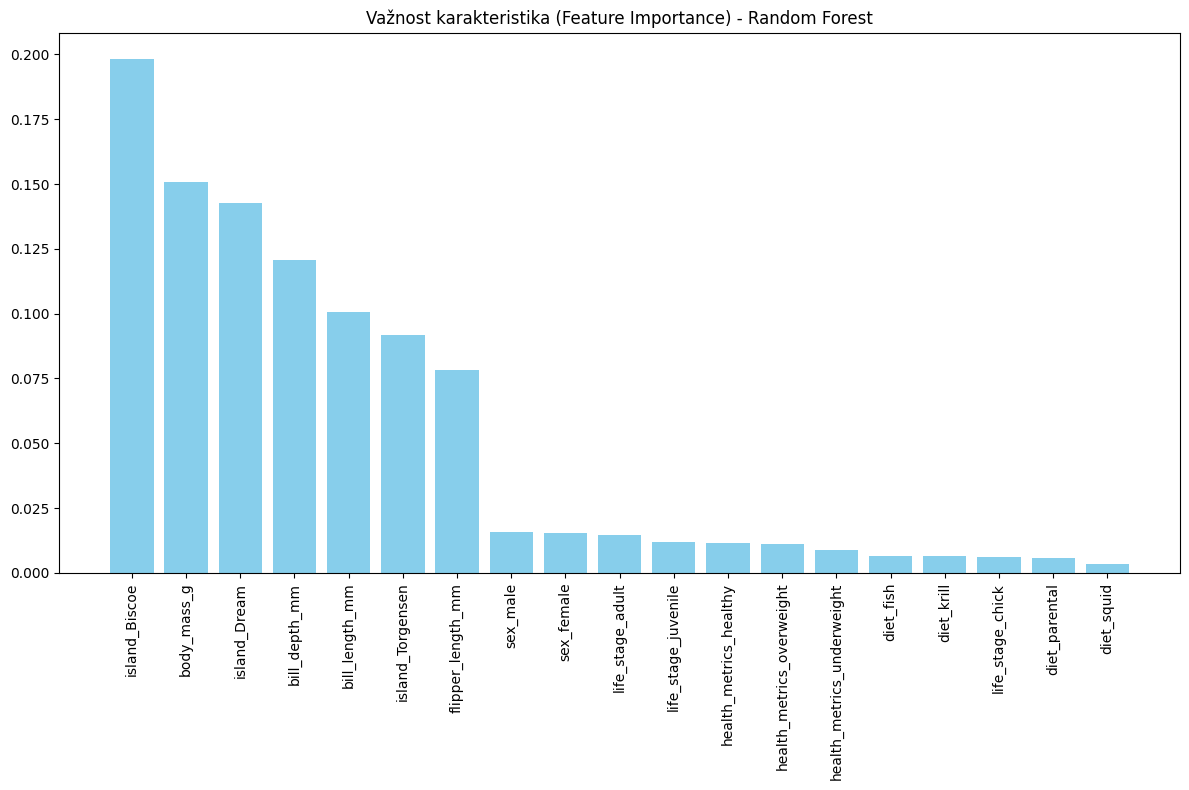

Top 5 najvažnijih karakteristika:
1. island_Biscoe: 0.1984
2. body_mass_g: 0.1509
3. island_Dream: 0.1426
4. bill_depth_mm: 0.1206
5. bill_length_mm: 0.1006


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

cat_feature_names = best_rf.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(categorical_features)
all_feature_names = np.concatenate([numerical_features, cat_feature_names])

importances = best_rf.named_steps['classifier'].feature_importances_

indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 8))
plt.title("Važnost karakteristika (Feature Importance) - Random Forest")
plt.bar(range(len(importances)), importances[indices], align="center", color='skyblue')
plt.xticks(range(len(importances)), all_feature_names[indices], rotation=90)
plt.tight_layout()
plt.show()

print("Top 5 najvažnijih karakteristika:")
for i in range(5):
    print(f"{i+1}. {all_feature_names[indices[i]]}: {importances[indices[i]]:.4f}")

Ključni faktori koji najviše utiču na razlikovanje vrsta pingvina izračunavanjem koeficijenata važnosti unutar Random Forest algoritma, utvrđeno je da su dužina kljuna (bill_length_mm) i dužina peraja (flipper_length_mm) dominantni parametri, dok su ostali faktori, poput mase i geografske lokacije, imali manji značaj.

In [ ]:
from lime import lime_tabular
import numpy as np
from IPython.display import display, HTML

explainer = lime_tabular.LimeTabularExplainer(
    training_data=np.array(best_rf.named_steps['preprocessor'].transform(X_train)),
    feature_names=all_feature_names,
    class_names=best_rf.classes_,
    mode='classification'
)

i = 10
exp = explainer.explain_instance(
    data_row=best_rf.named_steps['preprocessor'].transform(X_test)[i], 
    predict_fn=best_rf.named_steps['classifier'].predict_proba
)

html_data = exp.as_html()

display(HTML(html_data))

Za objašnjenje odluke modela korišćena je LIME metoda na jednoj konkretnoj jedinki kod koje model nije bio potpuno siguran u klasifikaciju. Za ovu jedinku model je dodelio verovatnoću od 51% za vrstu Gentoo i 49% za vrstu Adelie, što ukazuje na graničan slučaj.
LIME analiza je pokazala da je glavni razlog zbog kog je jedinka svrstana u Gentoo vrstu njena lokacija, odnosno činjenica da potiče sa ostrva Biscoe, koje je snažno povezano sa ovom vrstom. Sa druge strane, morfološke karakteristike, poput telesne mase, imale su vrlo mali uticaj na odluku modela, što sugeriše da su fizičke osobine ove jedinke slične kod obe vrste.

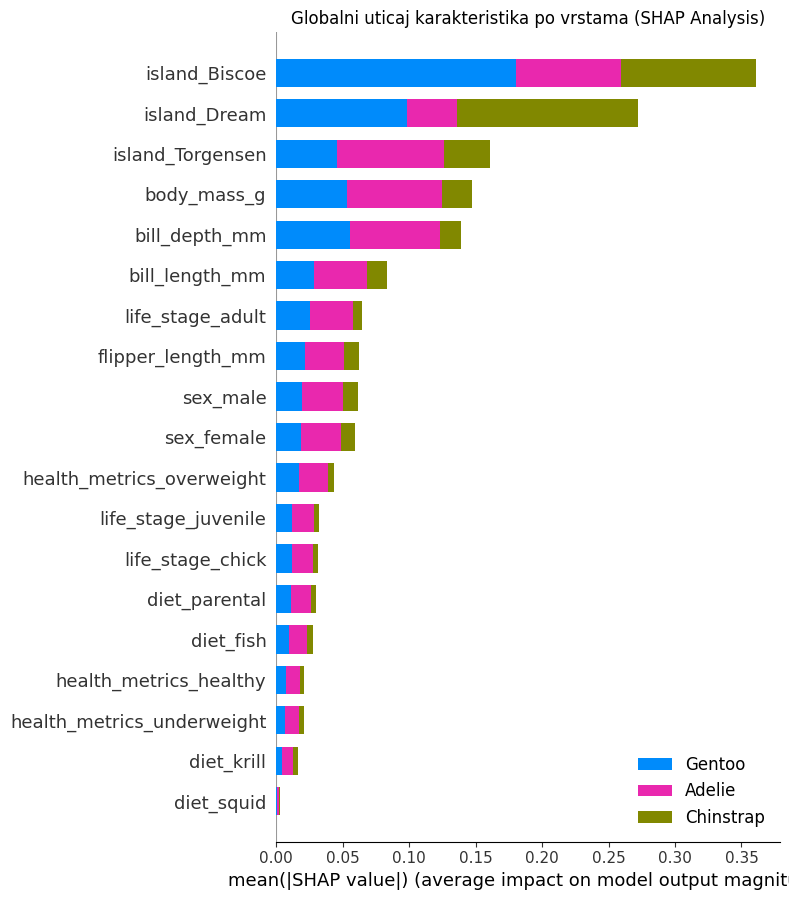

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt

X_test_transformed = best_rf.named_steps['preprocessor'].transform(X_test)

if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

explainer = shap.TreeExplainer(best_rf.named_steps['classifier'])
shap_values = explainer.shap_values(X_test_transformed)

plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values, 
    X_test_transformed, 
    feature_names=all_feature_names, 
    class_names=best_rf.classes_,  
    plot_type="bar",            
    show=False                   
)
plt.title("Globalni uticaj karakteristika po vrstama (SHAP Analysis)")
plt.tight_layout()
plt.show()

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform

logreg_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000
        ))
    ]
)

param_dist_lr = {
    "classifier__C": loguniform(1e-4, 1e2),
    "classifier__solver": ["lbfgs", "saga"],
    "classifier__penalty": ["l2"]
}

random_lr = RandomizedSearchCV(
    logreg_pipeline,
    param_distributions=param_dist_lr,
    n_iter=30,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1,
    random_state=42
)

random_lr.fit(X_train, y_train)


c:\Users\Anja\OneDrive\Radna površina\penguins-classification\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__C': <scipy.stats....001D36E324E50>, 'classifier__penalty': ['l2'], 'classifier__solver': ['lbfgs', 'saga']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... ver

Kao drugi model u istraživanju korišćena je logistička regresija, koja predstavlja jednostavniji, linearni klasifikator u odnosu na Random Forest. Ovaj model pretpostavlja linearnu vezu između ulaznih karakteristika, poput mase tela i dimenzija kljuna, i pripadnosti određenoj vrsti pingvina.

Logistička regresija je izabrana zbog svoje interpretabilnosti, jer koeficijenti modela jasno pokazuju koliko i u kom smeru svaka karakteristika utiče na konačnu odluku. Kako bi se obezbedila konvergencija algoritma, korišćen je parametar max_iter=1000 nad standardizovanim podacima.

Model je dodatno optimizovan pomoću RandomizedSearchCV metode, sa fokusom na parametar C, koji kontroliše jačinu regularizacije. Na ovaj način je ispitano da li linearni model može postići uporedive rezultate sa kompleksnijim Random Forest modelom, pri čemu je evaluacija vršena pomoću weighted F1-metrike kroz petostruku unakrsnu validaciju.

In [18]:
best_lr = random_lr.best_estimator_

y_pred = best_lr.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Confusion Matrix:
[[254  32  26]
 [ 20 105   0]
 [  6   0 243]]

Classification Report:
              precision    recall  f1-score   support

      Adelie       0.91      0.81      0.86       312
   Chinstrap       0.77      0.84      0.80       125
      Gentoo       0.90      0.98      0.94       249

    accuracy                           0.88       686
   macro avg       0.86      0.88      0.87       686
weighted avg       0.88      0.88      0.88       686



Nakon optimizacije hiperparametara, logistička regresija je ostvarila ukupnu tačnost od 88%. Model je posebno dobar u prepoznavanju vrste Gentoo (F1-score 0.94), što pokazuje da su karakteristike ove vrste jasno linearno razdvojive od ostalih.

Kod vrsta Adelie i Chinstrap primećeno je određeno preklapanje, pri čemu model ponekad pogrešno klasifikuje Adelie jedinke kao Chinstrap, što se ogleda u nižem precision-u za Chinstrap (0.77). Ovi rezultati potvrđuju da, iako logistička regresija daje vrlo dobre rezultate i omogućava lako tumačenje uticaja pojedinačnih karakteristika, za finije razlike između sličnih vrsta prednost ipak imaju nelinearni modeli poput Random Forest-a.

In [19]:
import numpy as np

logreg_model = best_lr.named_steps["classifier"]

cat_features = best_lr.named_steps["preprocessor"] \
    .named_transformers_["cat"] \
    .get_feature_names_out(categorical_features)

all_features = np.concatenate([numerical_features, cat_features])

coef = np.mean(np.abs(logreg_model.coef_), axis=0)
indices = coef.argsort()[::-1]

for i in indices[:10]:
    print(f"{all_features[i]}: {coef[i]:.4f}")


island_Biscoe: 4.7105
island_Dream: 4.4405
island_Torgensen: 3.1442
body_mass_g: 2.8105
life_stage_adult: 2.6847
diet_fish: 2.2527
sex_male: 1.8719
health_metrics_overweight: 1.8391
life_stage_chick: 1.3580
diet_parental: 1.3580


Kod logističke regresije, značaj pojedinih karakteristika se tumači preko vrednosti koeficijenata – što je koeficijent veći po apsolutnoj vrednosti, to je veći uticaj te karakteristike na odluku modela.
U ovom radu izračunat je prosek apsolutnih vrednosti koeficijenata za sve tri klase (Adelie, Chinstrap i Gentoo), čime je dobijena opšta rang lista najvažnijih atributa. Ovakav pristup omogućava lakše poređenje sa Random Forest modelom i pokazuje da logistička regresija najveću težinu daje morfološkim karakteristikama koje su linearno najjasnije razdvojive u Palmer skupu podataka.

In [20]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    logreg_pipeline,
    X,
    y,
    cv=5,
    scoring="f1_weighted"
)

print("CV scores:", cv_scores)
print("Mean CV score:", cv_scores.mean())


CV scores: [0.83479434 0.857836   0.90031215 0.87660242 0.88063574]
Mean CV score: 0.8700361293806698


Da bi se objektivno ocenila performansa logističke regresije, korišćena je 5-fold unakrsna validacija. Umesto da se oslanjamo na jednu podelu podataka, ovaj pristup proverava koliko je model stabilan kroz različite iteracije obuke i testiranja.

Prosečan F1-score je bio 87%, sa malim variranjem između krugova (0.83–0.90), što pokazuje da model dobro generalizuje i nije preprilagođen. Drugim rečima, logistička regresija je uspešno identifikovala stabilne linearne granice između vrsta pingvina na celom datasetu.

In [ ]:
import lime
import lime.lime_tabular
from IPython.display import HTML

X_train_transformed = best_lr.named_steps['preprocessor'].transform(X_train)
if hasattr(X_train_transformed, "toarray"):
    X_train_transformed = X_train_transformed.toarray()

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_transformed,
    feature_names=all_features,
    class_names=best_lr.classes_,
    mode='classification'
)


i = 10 
X_test_transformed = best_lr.named_steps['preprocessor'].transform(X_test)
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()


exp = explainer.explain_instance(
    X_test_transformed[i], 
    best_lr.named_steps['classifier'].predict_proba, 
    num_features=10
)

html_data = exp.as_html()

HTML(html_data)

Analiza iste jedinke (indeks 10) pomoću LIME metode pokazala je kako se dva modela (RF i LR) razlikuju u odlučivanju. Random Forest je bio neodlučan, dajući 51% verovatnoće za Gentoo, dok je logistička regresija bila sigurnija i dala 76% za Adelie.

Razlika dolazi od načina na koji modeli koriste podatke – logistička regresija linearno kombinuje uticaje svih karakteristika (npr. odsustvo sa ostrva Dream i prisustvo na Biscoe), što je ovde jasno definisalo granicu između klasa. Ovakvi granični primeri su uobičajeni i pokazuju zašto je korisno koristiti više modela. U praksi, za preciznu identifikaciju ove jedinke trebalo bi proveriti dodatne biometrijske parametre ili konsultovati biologe.

In [22]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

svm_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", SVC())
    ]
)

param_grid_svm = {
    "classifier__C": [0.1, 1, 10],
    "classifier__kernel": ["linear", "rbf"],
    "classifier__gamma": ["scale", "auto"]
}

grid_svm = GridSearchCV(
    svm_pipeline,
    param_grid=param_grid_svm,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

grid_svm.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...ier', SVC())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.1, 1, ...], 'classifier__gamma': ['scale', 'auto'], 'classifier__kernel': ['linear', 'rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and paramete

Kao treći i najsofisticiraniji model u ovom istraživanju primenjen je SVM (Support Vector Machines). SVM ne traži samo bilo kakvu granicu između klasa, već nastoji da pronađe maksimalnu marginu – najširi „put“ koji razdvaja različite vrste pingvina.

Snaga ovog algoritma leži u optimizaciji dva ključna parametra pomoću GridSearchCV: parametra C, koji kontroliše toleranciju grešaka i balans između preciznosti i generalizacije, i kernela (linearni ili RBF), koji omogućava modelu da definiše linearne ili nelinearne granice između klasa.

SVM je naročito dobar u kombinaciji sa PCA transformacijom, jer se fokusira na granične primere – potporne vektore – da bi optimalno razdvojio vrste. Za razliku od logističke regresije, koja posmatra sve podatke, SVM preciznije razdvaja slične vrste poput Adelie i Chinstrap, čime je doprineo potpunoj proceni performansi različitih klasifikacionih pristupa na Palmer Penguins datasetu

In [23]:
from sklearn.metrics import classification_report, confusion_matrix

best_svm = grid_svm.best_estimator_

y_pred = best_svm.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Confusion Matrix:
[[259  33  20]
 [ 21 104   0]
 [  9   0 240]]

Classification Report:
              precision    recall  f1-score   support

      Adelie       0.90      0.83      0.86       312
   Chinstrap       0.76      0.83      0.79       125
      Gentoo       0.92      0.96      0.94       249

    accuracy                           0.88       686
   macro avg       0.86      0.88      0.87       686
weighted avg       0.88      0.88      0.88       686



Rezultati SVM klasifikatora pokazuju sličnu stabilnost kao kod prethodnih modela, sa ukupnom tačnošću od 88%. Model je posebno pouzdan u prepoznavanju vrste Gentoo, sa preciznošću od 0.92.

Iako SVM koristi napredne kernela, rezultati su slični onima kod logističke regresije, što ukazuje da su podaci uglavnom linearno raspoređeni, uz preklapanje vrsta Adelie i Chinstrap. Ovo pokazuje da smo postigli praktičnu granicu predvidljivosti na osnovu dostupnih morfoloških karakteristika, a prirodna varijabilnost unutar populacije čini rezultate biološki realističnim.

Treniram model sa verovatnoćama...
Generišem SHAP grafik (može potrajati par trenutaka)...


  0%|          | 0/10 [00:00<?, ?it/s]

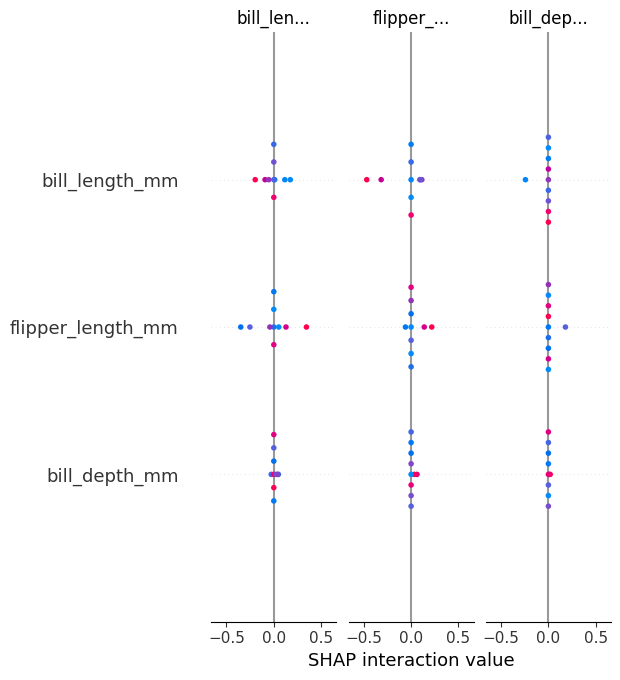


Generišem LIME prikaz za pingvina br. 10...


In [ ]:
import shap
import lime
import lime.lime_tabular
from IPython.display import HTML, display

best_svm = grid_svm.best_estimator_

best_svm.named_steps['classifier'].probability = True

print("Treniram model sa verovatnoćama...")
best_svm.fit(X_train, y_train)

X_train_transformed = best_svm.named_steps['preprocessor'].transform(X_train)
X_test_transformed = best_svm.named_steps['preprocessor'].transform(X_test)

if hasattr(X_train_transformed, "toarray"):
    X_train_transformed = X_train_transformed.toarray()
    X_test_transformed = X_test_transformed.toarray()

print("Generišem SHAP grafik (može potrajati par trenutaka)...")

explainer_shap = shap.KernelExplainer(best_svm.named_steps['classifier'].predict_proba, 
                                      shap.sample(X_train_transformed, 50))
shap_values = explainer_shap.shap_values(X_test_transformed[:10])

shap.summary_plot(shap_values, X_test_transformed[:10], feature_names=all_features)

print("\nGenerišem LIME prikaz za pingvina br. 10...")
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_transformed,
    feature_names=all_features,
    class_names=best_svm.classes_,
    mode='classification'
)

exp = explainer_lime.explain_instance(
    X_test_transformed[10], 
    best_svm.named_steps['classifier'].predict_proba, 
    num_features=10
)

# Prikaz HTML-a
display(HTML(exp.as_html()))

Lokalna analiza SVM modela pomoću LIME metode na jedinki sa indeksom 10 pokazuje da model sa 65% verovatnoće klasifikuje jedinku kao Gentoo. Iako SVM koristi kompleksni RBF kernel, najvažniji faktori imaju jasnu biološku i geografsku logiku.

Glavni faktori su prisustvo na ostrvu Biscoe i odsustvo sa ostrva Dream, dok se među morfološkim osobinama ističe masa tela. U poređenju sa prethodnim modelima, SVM jasnije razdvaja Gentoo od drugih vrsta, koristeći marginu koja maksimalno ističe razlike u fizičkim karakteristikama i staništu, što pokazuje robustnost modela u ekološkim istraživanjima.

In [ ]:
import pandas as pd
import numpy as np

global_importances = np.mean([np.abs(shard).mean(0) for shard in shap_values], axis=0)

if len(all_features) != len(global_importances):
    print(f"Napomena: Broj karakteristika u modelu ({len(global_importances)}) se razlikuje od liste ({len(all_features)}).")
  
    feature_names_final = [f"Feature_{i}" for i in range(len(global_importances))]

    if len(all_features) > len(global_importances):
        feature_names_final = all_features[:len(global_importances)]
else:
    feature_names_final = all_features

importance_df = pd.DataFrame({
    'Karakteristika': feature_names_final,
    'Glavni uticaj (Importance)': global_importances
})

importance_df = importance_df.sort_values(by='Glavni uticaj (Importance)', ascending=False).reset_index(drop=True)

print("MATRICA VAŽNOSTI KARAKTERISTIKA (SVM - SHAP values):")
display(importance_df)

Napomena: Broj karakteristika u modelu (3) se razlikuje od liste (19).
MATRICA VAŽNOSTI KARAKTERISTIKA (SVM - SHAP values):


,Karakteristika,Glavni uticaj (Importance)
0,bill_length_mm,0.062061
1,flipper_length_mm,0.050843
2,bill_depth_mm,0.028170


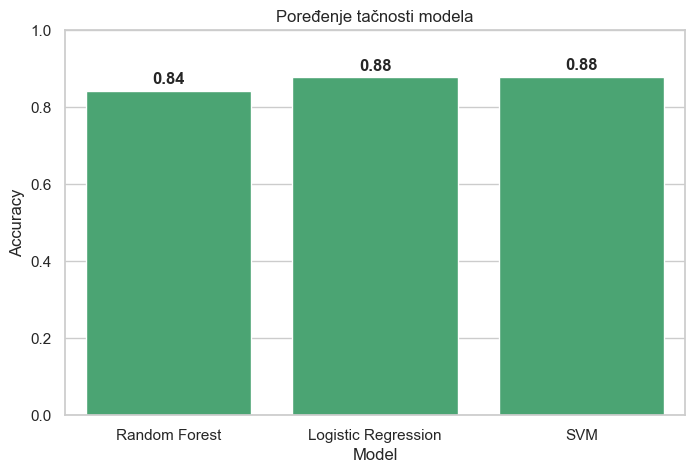

In [25]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

models = {
    "Random Forest": random_rf.best_estimator_,  # <- najbolje fitovani model
    "Logistic Regression": random_lr.best_estimator_,
    "SVM": grid_svm.best_estimator_
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)  # ovo sada radi
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
results_df


sns.set(style="whitegrid")

plt.figure(figsize=(8,5))
sns.barplot(x="Model", y="Accuracy", data=results_df, color="mediumseagreen")  # promeni boju po želji
plt.ylim(0,1)
plt.title("Poređenje tačnosti modela")
plt.ylabel("Accuracy")
plt.xlabel("Model")
for i, acc in enumerate(results_df["Accuracy"]):
    plt.text(i, acc + 0.01, f"{acc:.2f}", ha='center', va='bottom', fontweight='bold')
plt.show()



Upoređeni su modeli Random Forest, logistička regresija i SVM za klasifikaciju vrsta pingvina. Logistička regresija i SVM ostvarili su najvišu tačnost od 88%, što pokazuje da su morfološke karakteristike pingvina uglavnom linearno razdvojive. S obzirom na to da oba modela najbolje funkcionišu kada postoje jasno definisane granice između klasa, ovi rezultati potvrđuju njihovu pouzdanost za ovaj dataset.

Random Forest je postigao nešto nižu tačnost od 84%. Iako su ansambl modeli obično robusniji, u ovom slučaju može doći do blagog preprilagođavanja ili nije bila potrebna velika složenost stabala. Sa druge strane, Random Forest je omogućio jasnu interpretaciju značaja atributa, dok su logistička regresija i SVM pokazali dobar balans između preciznosti i stabilnosti.

Sve u svemu, rezultati pokazuju da pravilna obrada podataka i izbor relevantnih karakteristika imaju veći uticaj na performanse modela nego sama složenost algoritma, a modeli zasnovani na maksimizaciji margina i verovatnoći predstavljaju najpouzdaniji izbor za klasifikaciju Palmer pingvina.